In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/beamhonor0911/spotify-artist-streaming-analytics-20202025/spotify_artist_streaming_2020_2025.csv


# Spotify Streaming Data Analysis

## Project Overview

In this project, I analyze Spotify streaming data to explore what factors are associated with song streaming performance.

The analysis focuses on questions such as:
- Which music genres receive the most streams?
- Which artists receive the most streams?
- Is Spotify popularity related to streaming performance?
- Do characteristics such as danceability and energy relate to streams?
- Do explicit and non-explicit songs perform differently?
- Does the timing of a song's release relate to its streaming performance?
- Which numerical features have the strongest correlations with streams?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df = pd.read_csv("/kaggle/input/datasets/beamhonor0911/spotify-artist-streaming-analytics-20202025/spotify_artist_streaming_2020_2025.csv")

/kaggle/input/datasets/beamhonor0911/spotify-artist-streaming-analytics-20202025/spotify_artist_streaming_2020_2025.csv


In [3]:
# =========================
# DATA CLEANING / QUALITY CHECKS
# =========================

# Check missing values
print(df.isnull().sum())

# Check duplicate rows
print(df.duplicated().sum())

# Check data types
print(df.dtypes)

# Check basic statistics
print(df[["stream_count", "popularity", "duration_ms", "danceability", "energy"]].describe())

# Check Negative Stream Count
print((df["stream_count"] < 0).sum())
print((df["stream_count"] == 0).sum())


# Check text/category consistency
print(df["release_year"].unique())
print(df["genre"].unique())
print(df["release_day_of_week"].unique())
print(df["country"].unique())

track_id               0
track_name             0
artist_name            0
album_name             0
release_date           0
genre                  0
duration_ms            0
popularity             0
danceability           0
energy                 0
key                    0
loudness               0
mode                   0
instrumentalness       0
tempo                  0
stream_count           0
country                0
explicit               0
label                  0
release_year           0
release_month          0
release_day_of_week    0
duration_minutes       0
popularity_category    0
loudness_category      0
key_name               0
mode_name              0
is_explicit_bool       0
release_quarter        0
is_weekend_release     0
log_stream_count       0
upbeat_score           0
artist_track_count     0
dtype: int64
0
track_id                object
track_name              object
artist_name             object
album_name              object
release_date            object
genre

## Exploratory Data Analysis

### 1. Which Genres Receive the Most Streams?

To determine which music genres receive the most streams, I grouped the songs by genre and calculated the total number of streams for each genre.

In [4]:
streams_total = df.groupby('genre')['stream_count'].sum().reset_index()
sort_stream = streams_total.sort_values(by='stream_count', ascending=False, ignore_index=True)
sort_stream 

,genre,stream_count
0,Pop,1649081624
1,R&B,1458281734
2,Hip-Hop,436093929
3,Latin,340782388
4,Rock,314706623
5,EDM,292418495
6,Folk,227814482
7,Metal,212286827
8,Country,168178253
9,K-Pop,153095403


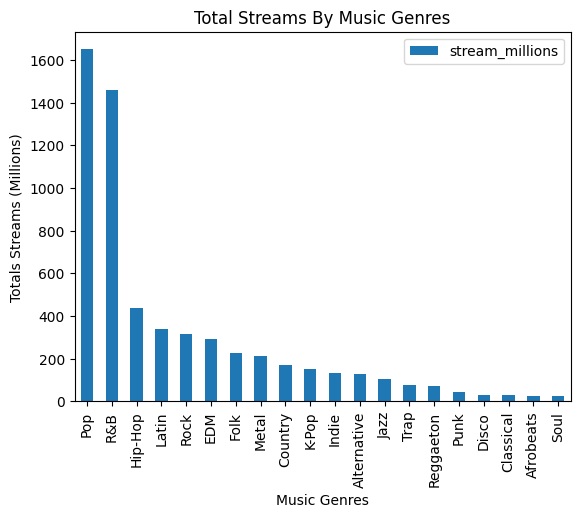

In [5]:
sort_stream["stream_millions"] = sort_stream["stream_count"] / 1_000_000

sort_stream.plot(
    kind="bar",
    x = "genre", 
    y ="stream_millions",
)

plt.title("Total Streams By Music Genres")
plt.xlabel("Music Genres")
plt.ylabel("Totals Streams (Millions)")
plt.xticks(rotation=90)
plt.show()

#### Interpretation

The results show that Pop was the genre with the highest total number of streams. Compared to the other groups R&B was its closest competitor that was also over 1 billion streams afterwards all the other genres fell well below 500 million streams. This suggests that streaming activity in this dataset is heavily concentrated in Pop and R&B, compared to the other genres.

### 2. Which Artists Receive the Most Streams?

To identify the artists with the most streams, I grouped the data by artist and calculated the total stream count for each artist.

In [6]:
stream_artist_totals = df.groupby('artist_name')['stream_count'].sum().reset_index()
sort_artist_stream = stream_artist_totals.sort_values(by='stream_count', ascending=False, ignore_index=True)
most_artist_stream = sort_artist_stream.iloc[0]
print(sort_artist_stream.head(10))

    artist_name  stream_count
0     Knot Hart    1303217036
1      IsleEyre     669929807
2      Ethereal     433176636
3  Sterling Zen     245065284
4     Rocco Ore     219663605
5     SethStone     179681824
6     ElaraRain     132996215
7     ValeGlass     120591894
8    Frost Nova     104088727
9     The Dawns      99573871


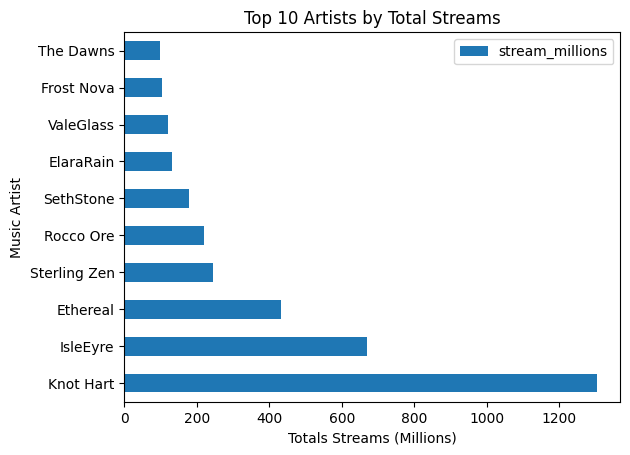

In [7]:
sort_artist_stream["stream_millions"] = sort_artist_stream["stream_count"] / 1_000_000

sort_artist_stream.head(10).plot(
    kind ="barh",
    x = "artist_name",
    y = "stream_millions",
)
plt.xticks(rotation=0)

plt.title("Top 10 Artists by Total Streams")
plt.ylabel("Music Artist")
plt.xlabel("Totals Streams (Millions)")

plt.show()

#### Interpretation

The results show that Knot Hart was the top artist based on total number of streams in the dataset with 1.2 billion streams. The next closest artists fell below 800 million streams, with IsleEyre ranking second. Based on the graph there is a massive drop-off from 1st to 2nd place, while the drop-off gets smaller the lower down the list you go. This suggests that Knot Hart is a significant outlier among the top-streamed artists in this dataset.

### 3. How Have Streams Changed From 2020–2025?

To examine how streaming performance changed over time, I calculated the total streams for songs released in each year from 2020 to 2025. I also calculated the year-to-year change in total streams.

In [8]:
sort_release_year = df.groupby('release_year')['stream_count'].sum() #.reset_index()
sort_release_change = sort_release_year.diff()
print(sort_release_year)
print(sort_release_change)

release_year
2020     954150849
2021     921810832
2022     922052493
2023    1009133660
2024    1065121362
2025    1046677018
Name: stream_count, dtype: int64
release_year
2020           NaN
2021   -32340017.0
2022      241661.0
2023    87081167.0
2024    55987702.0
2025   -18444344.0
Name: stream_count, dtype: float64


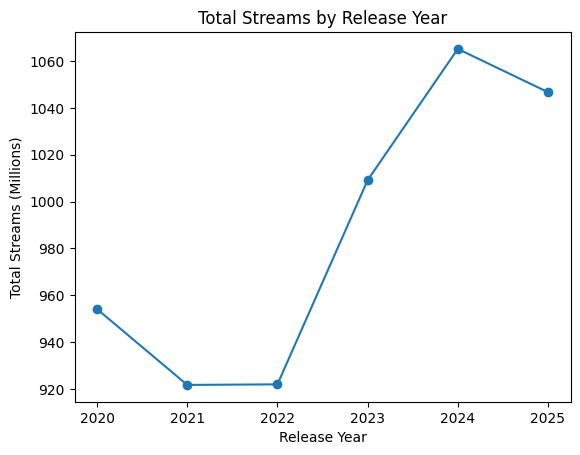

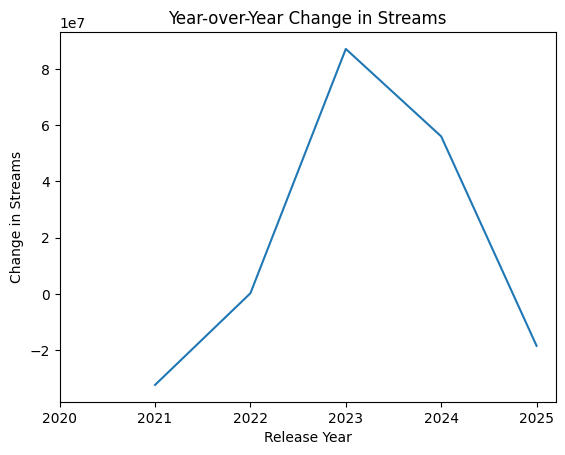

In [9]:
(sort_release_year / 1_000_000).plot(
    kind="line",
    marker="o"
)

plt.title("Total Streams by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Total Streams (Millions)")
plt.xticks([2020, 2021, 2022, 2023, 2024, 2025])

plt.show()


sort_release_change.plot(kind="line")
plt.title("Year-over-Year Change in Streams")
plt.xlabel("Release Year")
plt.ylabel("Change in Streams")
plt.xticks(
    [2020, 2021, 2022, 2023, 2024, 2025],
    rotation=0
)
plt.show()

#### Interpretation

The results show that the year with the highest total streams was 2024. From 2020-2025 the streams decreased from 2020-2021, remained unchanged from 2021-2022 but then increased afterwards in 2023 and 2024. The year with the largest increase was from 2023 to 2024. Overall, songs released in the later years of the dataset, particularly 2023-2025, accumulated more streams than songs released in 2020–2022.

However, these results do not necessarily mean that Spotify streaming increased during those years. The analysis groups songs by their release year, so it shows the total streams accumulated by songs released in each year rather than the total amount of Spotify streaming activity that occurred during each year.

### 4. Does Spotify popularity relate to streams?

0.40015864049421435


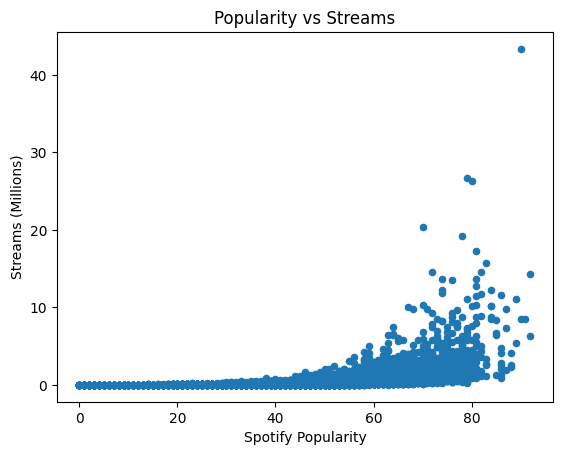

In [10]:
pop_stream = df['popularity'].corr(df['stream_count'])
print(pop_stream)

df["stream_millions"] = df["stream_count"] / 1_000_000

df.plot(kind="scatter",
       x = "popularity",
       y = "stream_millions")
plt.title("Popularity vs Streams")
plt.xlabel("Spotify Popularity")
plt.ylabel("Streams (Millions)")
plt.xticks(rotation=0)
plt.show()

#### Interpretation

The stream mainly hover around the lower stream counts as popularity increases. However, songs with higher popularity tend to have a wider range of streams, including the higher streamed songs. 
There is one main outlier that is above 40 million streams. 

The relationship on the graph is not strong, as songs with similar popularity scores can have varying stream numbers. There is a moderate positive relationship indicated by the correlation between the popularity and stream count being 0.40.

### 5. Do explicit songs receive more streams than non-explicit songs?

In [11]:
ex_perform = df.groupby('explicit')['stream_count'].mean()
print(ex_perform)

explicit
False    119100.495130
True     116196.555779
Name: stream_count, dtype: float64


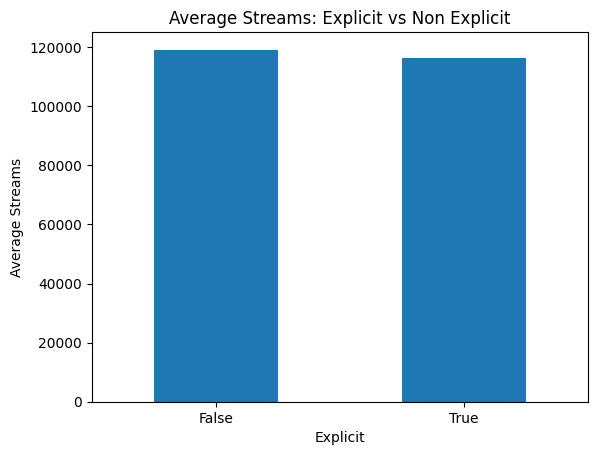

In [12]:
ex_perform.plot(kind = "bar")
plt.title("Average Streams: Explicit vs Non Explicit")
plt.xlabel("Explicit")
plt.ylabel("Average Streams")
plt.xticks(rotation=0)

plt.show()

#### Interpretation

The results show that Non Explicit had the highest average stream count. The difference between Non Explicit and Explicit is less than 3000. The difference is very small between both groups. Based on this dataset, non-explicit songs had slightly higher average streams than explicit songs, but the small difference suggests that explicit status may not have a major relationship with stream count.

### 6. Does Danceability Relate to Stream Count?

In [13]:
dance_songs = df["danceability"].corr(df["stream_count"])
print(dance_songs)

-0.003070838395740187


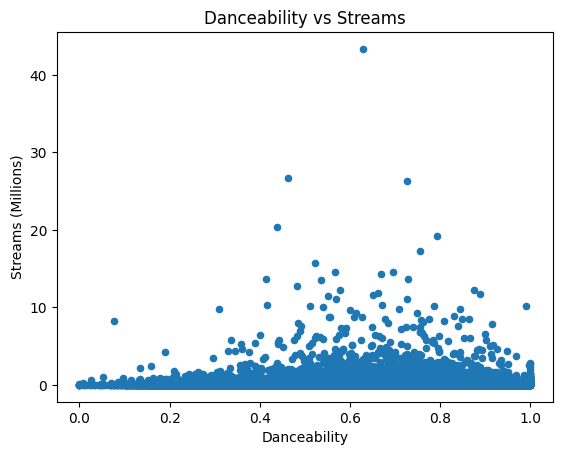

In [14]:
df["stream_millions"] = df["stream_count"] / 1_000_000

df.plot(
    kind="scatter",
    x="danceability",
    y="stream_millions"
)

plt.title("Danceability vs Streams")
plt.xlabel("Danceability")
plt.ylabel("Streams (Millions)")
plt.xticks(rotation=0)

plt.show()

#### Interpretation

The results show that there is no correlation between stream increasing and danceability increasing. Most of the highest stream songs are around the 0,4-0.8 danceability range. The graphs shows the points are very spread out. The major outliers are above 40 million streams, with a danceability above 0.6. 

The correlation of -0.003 is extremely close to zero, meaning that there is no linear relationship between danceability and stream count in this dataset.

### 7. Does energy relate to stream count?

In [15]:
high_eng_songs = df["energy"].corr(df["stream_count"])
print(high_eng_songs)

0.004273884777281387


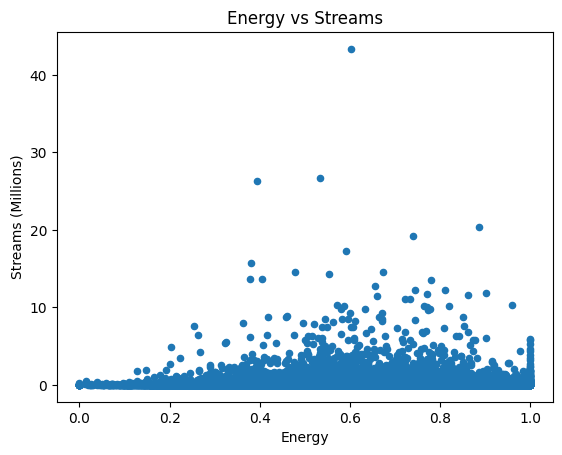

In [16]:
df["stream_millions"] = df["stream_count"] / 1_000_000

df.plot(
    kind="scatter",
    x="energy",
    y="stream_millions"
)

plt.title("Energy vs Streams")
plt.xlabel("Energy")
plt.ylabel("Streams (Millions)")
plt.xticks(rotation=0)

plt.show()

#### Interpretation

The results show that the highest stream songs are around the 0.4-0.8 energy levels. This means the songs are spread across many different energy levels without a clear upward or downward pattern. The major outlier is the one song with over 40 million streams, while the next highest songs are below 30 million streams. 

The correlation between energy and stream count is 0.0043 which is extremely close to zero. This means that essentially there is no linear relationship between energy and stream count. Based on this dataset it shows that higher energy doesn't have much of a relationship with higher stream count.

### 8. Which countries have the highest average stream counts?

In [17]:
high_count_stream = df.groupby("country")["stream_count"].mean().reset_index()
sort_high_count = high_count_stream.sort_values(by = "stream_count", ascending = False, ignore_index = True)
print(sort_high_count)

   country   stream_count
0       EG  168232.192678
1       NZ  140064.931864
2       IT  139159.361687
3       PT  137310.692759
4       NL  137024.696970
5       MX  130794.488263
6       CO  127658.218378
7       SE  127444.584442
8       SG  127423.844358
9       NG  126740.301065
10      ES  126310.220588
11      KR  125794.292440
12      CL  122225.314922
13      MY  121938.119691
14      IN  119147.062821
15      PH  119042.571152
16      AR  118864.954945
17      AU  118783.093083
18      BR  118597.681923
19      GB  117580.126167
20      JP  116587.959302
21      PL  114575.383648
22      CA  114465.510359
23      DE  113736.199673
24      US  113181.540319
25      TH  110144.620952
26      FR  101157.827154
27      ID   99098.993958
28      ZA   94793.825832
29      TR   90612.653808


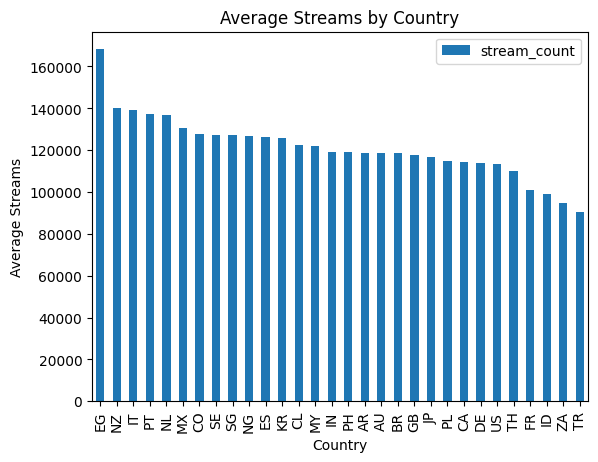

In [18]:
sort_high_count.plot(
    kind="bar",
    x="country",
    y="stream_count"
)

plt.title("Average Streams by Country")
plt.xlabel("Country")
plt.ylabel("Average Streams")
plt.xticks(rotation=90)

plt.show()

#### Interpretation

The results show that Egypt has the highest average streams with over 168,000 average streams. The next highest country is New Zealand with around 140,000 average streams, meaning Egypt has approximately 28,000 more average streams. The majority of the countries in the top 20 hover around the 110,000 - 140,000 range for average streams. The country with the lowest averages would be Indonesia (ID), South Africa (ZA), Turkey (TR). 

This shows that the country variable represents whatever country association the dataset gives each observation. You're comparing songs associated with each country, not measuring the total streaming behaviour of each country's population.


### 9. What is the distribution of Spotify popularity scores?

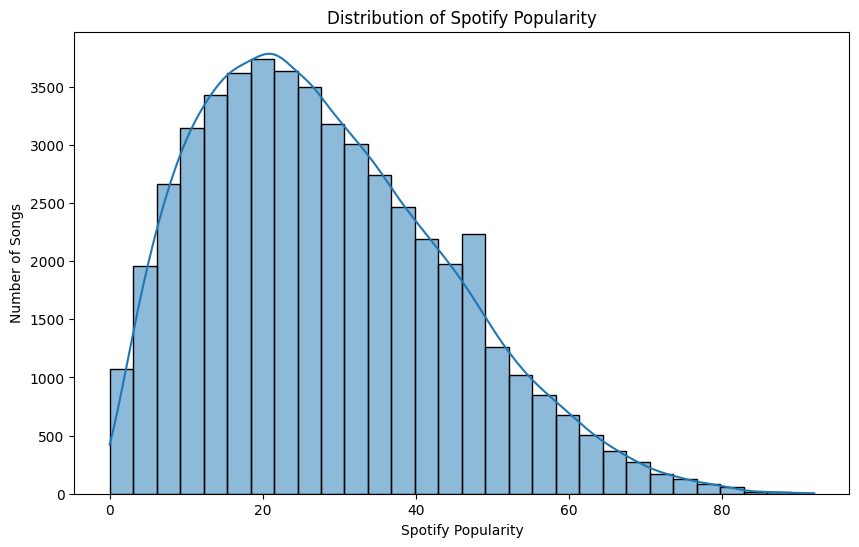

In [19]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df,
             x="popularity",
             bins=30, 
             edgecolor= "black",
             kde=True)

plt.title("Distribution of Spotify Popularity")
plt.xlabel("Spotify Popularity")
plt.ylabel("Number of Songs")

plt.show()

#### Interpretation

The results show that most songs were concentrated around the 20–40 Spotify popularity level. The highest peak is approximately around the 20 popularity level. At the very low end, there are fewer songs, then the number of songs quickly increases toward the 15–25 range. After the peak, the number gradually decreases as popularity increases, with very few songs above 70–80.

The overall shape is right-skewed. The KDE line demonstrates its highest point around a popularity score of 20 and then gradually declines toward the higher popularity scores. This reinforces that the distribution is right-skewed. Based on the graph, most songs have low-to-moderate popularity scores on Spotify, while songs with very high popularity scores are relatively uncommon.

### 10. What is the distribution of song durations?

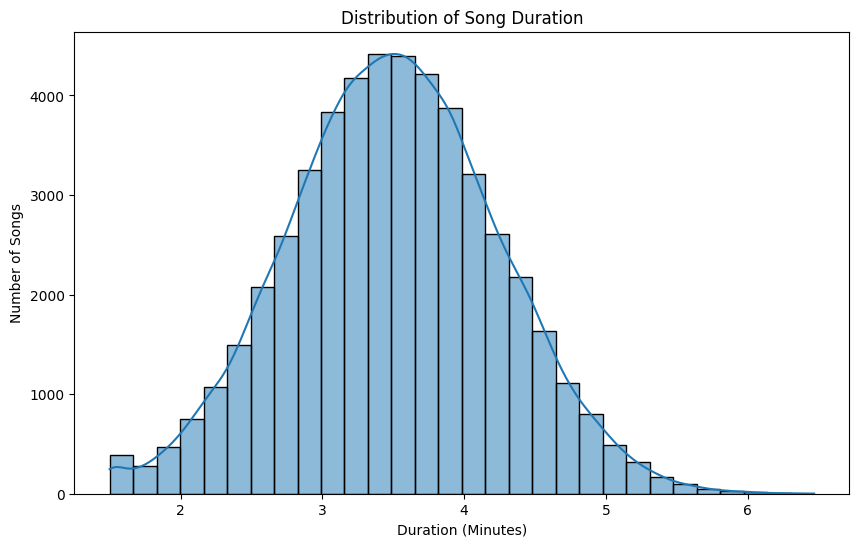

In [20]:
df["duration_minutes"] = df["duration_ms"] / 60000

plt.figure(figsize=(10, 6))

sns.histplot(data=df,
             x= "duration_minutes", 
             bins=30,
             edgecolor= "black",
             kde=True)

plt.title("Distribution of Song Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Songs")

plt.show()

#### Interpretation

The results show that most of the songs are in the duration range of 3–4 minutes. The highest peak on the histogram is around the 3.5-minute duration level. At the extremes, there are very few songs below 2 minutes or above 5–6 minutes compared to the 3–4 minute range.

The shape of the dataset is roughly symmetric and bell-shaped. The KDE line shows its highest peak around the middle at approximately 3.5 minutes, then declines as songs become shorter or longer. The dataset shows that 3–4 minute songs are very common, while very short songs and songs longer than around 5 minutes are much less common. Overall, a typical song in this dataset is around 3–4 minutes long.

## Correlation Analysis

The correlation matrix below examines the linear relationships between the numerical variables in the dataset.

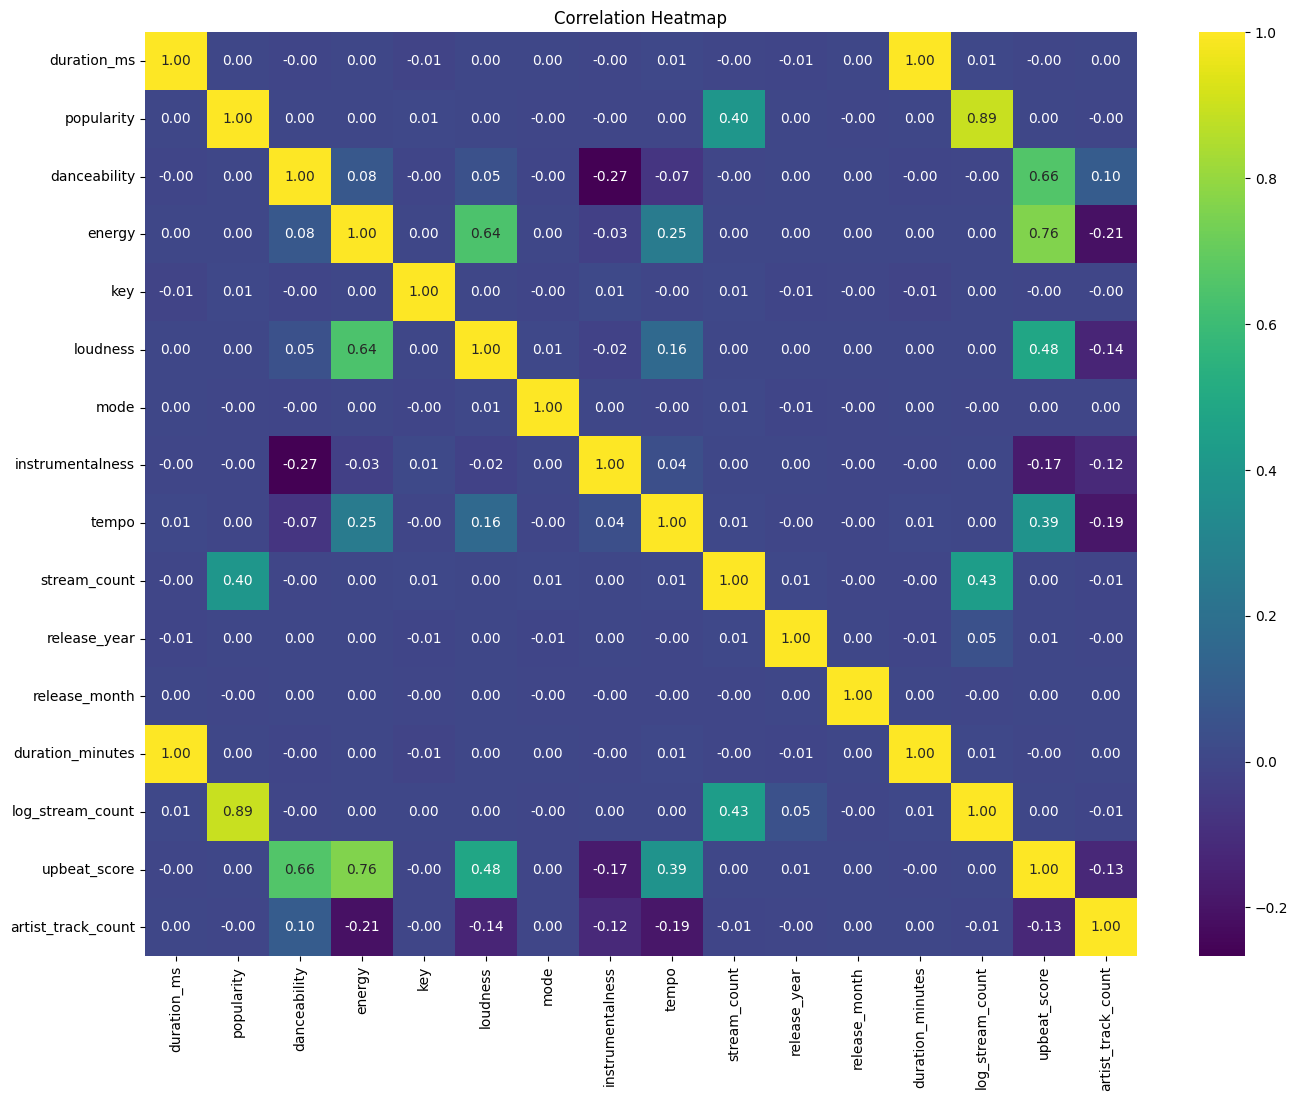

In [21]:
# Remove duplicate column first
df = df.drop(columns=["stream_millions"])

# Create correlation table AFTER removing it
correlation_table = df.select_dtypes(include="number").corr()

# Show correlations with stream_count
correlation_table["stream_count"].sort_values(ascending=False)

correlation_table

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_table,
    annot=True,
    cmap="viridis",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

#### Interpretation

The strongest positive correlation with stream_count, excluding variables derived from stream_count, is popularity. It has a correlation of approximately 0.40, indicating a moderate positive linear relationship.

Energy, danceability, loudness, instrumentalness, release month, and upbeat score all have correlations close to zero with stream count. This indicates that these variables have essentially no linear relationship with stream count in this dataset. 

Overall, the heatmap shows that popularity is the variable most related to streaming performance among the original variables examined. The majority of the other variables have correlations close to zero. This suggests that these individual audio characteristics do not have a strong linear relationship with streaming performance in this dataset.

However, correlation does not imply causation. Even though popularity and stream count are positively correlated, this does not mean that higher popularity directly causes a song to receive more streams, or that more streams alone cause a higher popularity score. Other factors not examined in this analysis could influence both variables.

## Key Findings and Conclusion

1. Genres: Pop had the highest total streams, followed by R&B.
2. Artists: Knot Hart was the most-streamed artist, with a large lead over the second-ranked artist.
3. Release Year: Songs released in 2024 accumulated the most streams, but this does not represent total Spotify activity during 2024.
4. Popularity: Popularity had a moderate positive correlation of 0.40 with stream count.
5. Audio Characteristics: Danceability and energy showed essentially no linear relationship with streams.
6. Explicit vs. Non-Explicit: Explicit vs. Non-Explicit songs had slightly higher average streams, but the difference was small.
7. Country: Egypt had the highest average streams among the countries analyzed.
8. Distributions: Most songs had popularity scores around 20–40 and durations around 3–4 minutes.
9. Correlations: Most audio characteristics had little to no linear correlation with streaming performance.
10. Overall: Popularity appeared more related to streaming performance than the individual audio characteristics examined. However, correlation does not prove causation.

### 💡 This analysis could be extended into:

- Streaming performance prediction
- Genre and artist comparisons
- Music trend analysis
- Further analysis of Spotify audio features

📊 **If you found this analysis useful, please consider upvoting the notebook!**